<a href="https://www.kaggle.com/code/bernardraymundo/deciphering-health-metrics-impact-insights-from-a?scriptVersionId=289484550" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

**Deciphering Health Metrics Impact: Insights from a Random Forest Model**


Background:
The utilized dataset file is from a study conducted by Professor Vera Novak and colleagues [(Novak et al., 2022)](https://physionet.org/content/cerebral-perfusion-diabetes/1.0.1/). This study investigates the effects of inflammation on perfusion regulation and brain volumes in type 2 diabetes. 

Objective: 
This data analysis project is focused on exploring the complex relationships between diabetes, inflammation, brain health, and physical function. The analysis and machine learning modeling using this dataset can provide insights into the pathological mechanisms of diabetes-related brain changes and their possible clinical manifestations. Developing and interpreting a Machine Learning model for a healthcare-related dataset. One of the critical goals is to understand the influence of specific health metrics  on the model's predictions. This analysis aims to uncover trends, patterns, or non-linear relationships between these features and the model's decision-making process.


Data Description (Summary)
- Participant Demographics: Data on age, diabetes status (diabetic or nondiabetic), and other demographic details.
- Clinical Measurements: Measurements of serum soluble vascular and intercellular adhesion molecules, which serve as markers of endothelial integrity, results that indicate vascular integrity and functioning.
- Cognitive and Physical Assessments: Data on cognitive functions, depression levels, and physical capabilities like walking speed.



Expected Outcome: 
Adoption and utilization of statistical methods and Machine Learning models, we aim to identify any significant trends or thresholds in the data that could inform medical professionals or data scientists about the critical factors influencing health outcomes as predicted by the analysis and model. This might be useful in providing leads to better-informed healthcare decisions and potentially improved patient care strategies.

**Exploratory Data Analysis (EDA)**


Steps executed:

1. Data Summarization: Understanding the basic structure of the dataset, including the number of rows and columns, types of variables, and missing values. 

2. Univariate Analysis: Analyzing the distribution of individual variables.

3. Bivariate or Multivariate Analysis: Exploring relationships between variables.

4. Identification of Trends, Patterns, and Outliers: Looking for any unusual data points or important patterns in the data.

In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Loading the data
UPLOADED_FILE = '/kaggle/input/novak-datafile/Novak et.Jal_DATA-FILE_CSV.csv'
data = pd.read_csv(UPLOADED_FILE)

# Displaying the first few rows of the data
data.head()

,patient ID,Visit,PREVIOUS TOBACCO USE,CURRENT TOBACCO USE,PackYears,Years,PREVIOUS ALCOHOL USE,CURRENT ALCOHOL USE,ALCOHOL Dose/Week,Dizziness AUTONOMIC SYMPTOMS,...,Left Eye Macular Edema,Macular Edema (more advanced eye),GAIT - Walk 1 distance (m),Gait (Normal) RPE Start (1-10),Gait (Normal) RPE End (1-10),Gait (DT) RPE Start (1-10),Gait (DT) RPE End (1-10),GAIT - Walk 1 speed (m/s),Gait (Dual Task) - Distance (m),Gait (Dual Task) - Speed (m/s)
0,S0030,2,No,No,NaN,NaN,NaN,Yes,2.0,NO,...,0,0,NaN,0.0,3.0,2.0,5.0,NaN,342.72,0.952000
1,S0033,2,Yes,No,40.0,40.0,Yes,Yes,1.0,NO,...,0,0,NaN,1.0,3.0,1.0,1.0,NaN,228.66,0.635167
2,S0064,2,No,No,NaN,NaN,Yes,Yes,0.0,NO,...,0,0,NaN,1.0,2.0,1.0,3.0,NaN,364.51,1.012528
3,S0068,2,NaN,No,NaN,NaN,NaN,No,0.0,NO,...,0,0,NaN,0.0,3.0,2.0,3.0,NaN,272.23,0.756194
4,S0078,2,No,No,NaN,NaN,Yes,Yes,0.0,NO,...,0,0,NaN,0.0,NaN,NaN,NaN,0.978139,NaN,NaN


In [2]:
# Data Summarization: Basic structure, types of variables, and missing values

# Basic structure
data_shape = data.shape

# Types of variables
data_types = data.dtypes

# Missing values
missing_values = data.isnull().sum()

# Preparing a summary for display
summary = {
    "Total Rows": data_shape[0],
    "Total Columns": data_shape[1],
    "Column Names": data.columns.tolist(),
    "Data Types": data_types.value_counts().to_dict(),
    "Columns with Most Missing Values": missing_values.idxmax(),
    "Number of Missing Values in Most Incomplete Column": missing_values.max(),
    "Total Missing Values": missing_values.sum()
}

summary



{'Total Rows': 121,
 'Total Columns': 170,
 'Column Names': ['patient ID',
  'Visit',
  'PREVIOUS TOBACCO USE',
  'CURRENT TOBACCO USE',
  'PackYears',
  'Years',
  'PREVIOUS ALCOHOL USE',
  'CURRENT ALCOHOL USE',
  'ALCOHOL Dose/Week',
  'Dizziness AUTONOMIC SYMPTOMS',
  'Numbness AUTONOMIC SYMPTOMS',
  'Painful feet AUTONOMIC SYMPTOMS',
  'Syncope AUTONOMIC SYMPTOMS',
  'OH AUTONOMIC SYMPTOMS',
  'cancer,# FAMILY HISTORY',
  'cancSpec FAMILY HISTORY',
  'HeartDisease FAMILY HISTORY',
  'Hdspecific FAMILY HISTORY',
  'HTN FAMILY HISTORY',
  'HTNspecific FAMILY HISTORY',
  'DM FAMILY HISTORY',
  'Dmspecific FAMILY HISTORY',
  'StrokeFAMILY HISTORY',
  'StrokeSpecific FAMILY HISTORY',
  'HTN YRS PATIENT MEDICAL HISTORY',
  'CANCER PATIENT MEDICAL HISTORY',
  'STROKE PATIENT MEDICAL HISTORY',
  'STROKE YR PATIENT MEDICAL HISTORY',
  'ATRIAL FIBTRILLATION PATIENT MEDICAL HISTORY',
  'HEART FAILURE =CHF /IFARCTION=-MI PATIENT MEDICAL HISTORY',
  'HYPERLIPIDEMIA PATIENT MEDICAL HISTORY',
  

**The initial exploratory data analysis (EDA) provides the following insights into the dataset:**

*     Total Rows: There are 121 rows in the dataset.

*     Total Columns: The dataset contains 170 columns.

*     Data Types: The majority of the columns (112) are of float type, followed by 47 object (string) type columns, and 11 integer type columns.

*     Columns with Most Missing Values: The column 'STROKE YR PATIENT MEDICAL HISTORY' has the most missing values, with all 121 entries missing.

*     Total Missing Values: There are 5665 missing values in the entire dataset.

Given the high number of columns, a wide range of variables is covered, including patient medical history, laboratory test results, and specific measurements related to diabetes and associated complications.

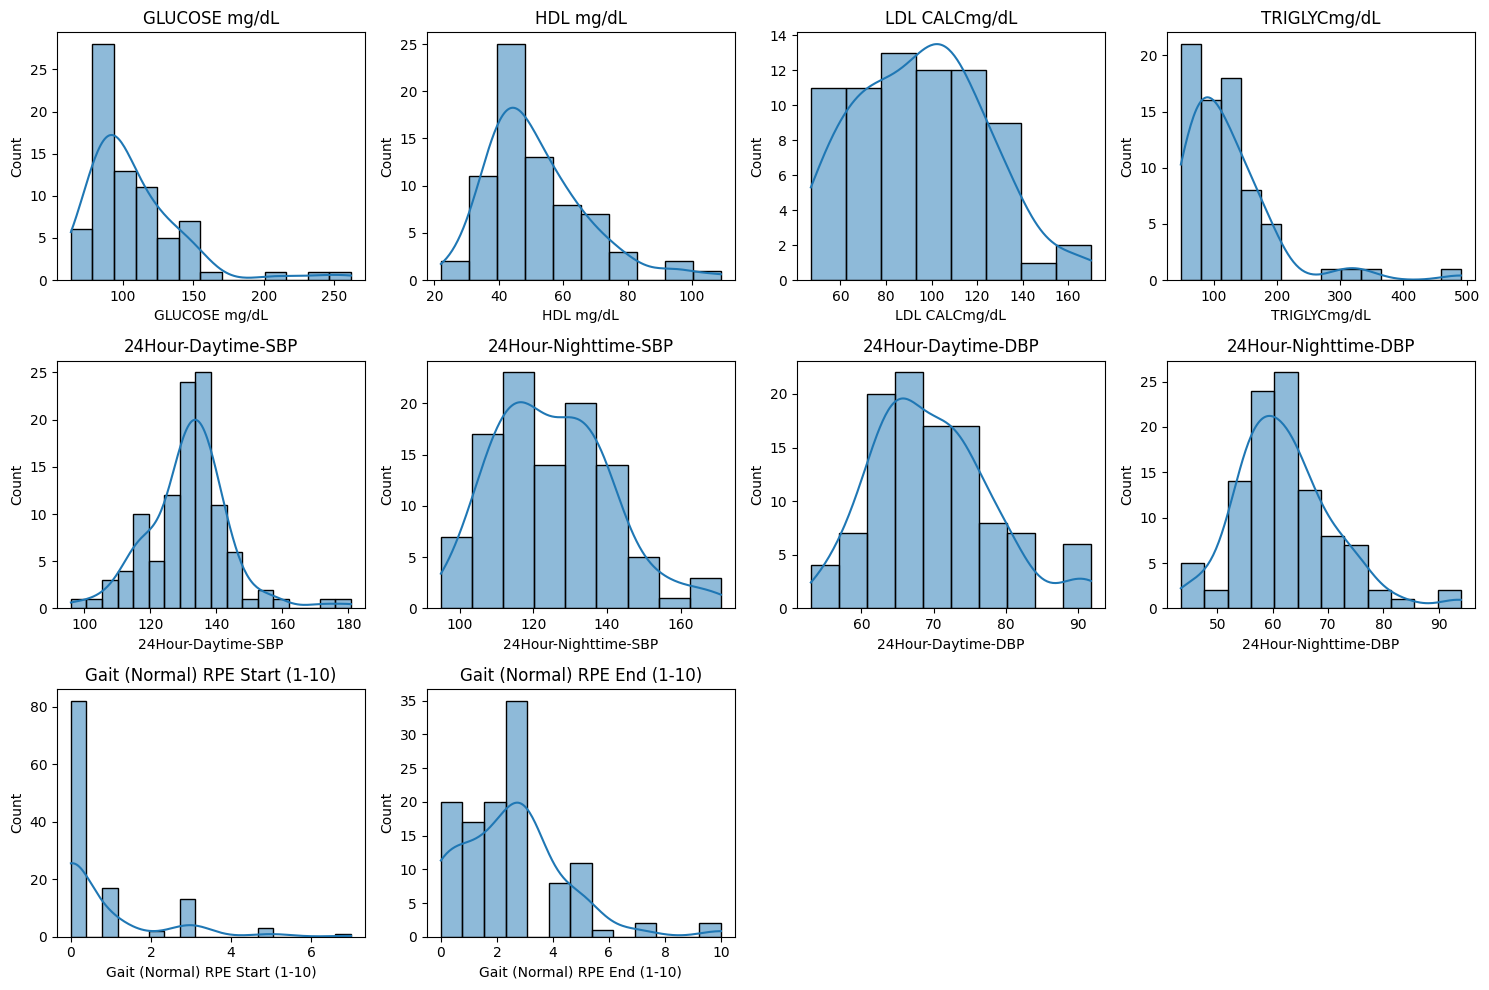

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out some key columns for univariate analysis
# Here we are selecting a few columns that might be of interest based on the study focus
key_columns = [
    'GLUCOSE mg/dL', 'HDL mg/dL', 'LDL CALCmg/dL', 'TRIGLYCmg/dL',
    '24Hour-Daytime-SBP', '24Hour-Nighttime-SBP', '24Hour-Daytime-DBP', 
    '24Hour-Nighttime-DBP', 'Gait (Normal) RPE Start (1-10)', 'Gait (Normal) RPE End (1-10)'
]

# Selecting only the key columns for univariate analysis
selected_data = data[key_columns]

# Univariate Analysis: Distribution plots for the selected variables
plt.figure(figsize=(15, 10))
for i, column in enumerate(selected_data.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(selected_data[column].dropna(), kde=True)
    plt.title(column)
    plt.tight_layout()

plt.show()


**Univariate Analysis of Key Health Metrics**

Overview:
This section of our analysis is dedicated to examining the distribution of selected health-related variables individually. The aim is to gain a deeper understanding of each variable's characteristics and distribution in the dataset.
 
 
1. Glucose Levels (mg/dL):
    * Significance: Glucose levels are a primary indicator of metabolic health, crucial in diagnosing and managing diabetes. Normal, pre-diabetic, 
      and diabetic conditions can be inferred from these levels.
    * Expected Insights: We aim to observe the distribution of glucose levels, looking for signs of normalcy or skewness towards higher levels, 
      which might indicate a prevalence of glucose intolerance or diabetes in the population.
      

2. HDL Cholesterol (mg/dL):
    * Significance: High-density lipoprotein (HDL) cholesterol is known as "good" cholesterol. Higher levels are often associated with a lower risk 
      of heart disease.
    * Expected Insights: The analysis will focus on the distribution of HDL levels, where higher values are generally desirable. A 
      left-skewed distribution could suggest a healthier profile in the population.
      

3. LDL Cholesterol (mg/dL):
    * Significance: Low-density lipoprotein (LDL) is often termed as "bad" cholesterol. High levels of LDL are linked to an increased risk of 
      heart disease.
    * Expected Insights: The distribution of LDL levels will be examined, with particular attention to any right-skewed patterns indicating prevalent 
      high LDL levels, a risk factor for cardiovascular diseases.
      

4. Triglycerides (mg/dL):
    * Significance: Triglycerides are a type of fat found in the blood. High levels are associated with an increased risk of heart disease, 
      especially when coupled with low HDL and high LDL levels.
    * Expected Insights: The goal is to assess the spread and central tendency of triglyceride levels, identifying any trends towards higher values 
      that might indicate metabolic health risks.
      

5. Blood Pressure Readings:
    * Significance: Blood pressure is a vital sign indicating the force of blood against artery walls. Both high (hypertension) and 
      low (hypotension) readings have significant health implications.
    * Variants: '24Hour-Daytime-SBP', '24Hour-Nighttime-SBP', '24Hour-Daytime-DBP', '24Hour-Nighttime-DBP'.
    * Expected Insights: We'll explore the distribution of systolic (SBP) and diastolic (DBP) blood pressures during different 
      times (daytime and nighttime). Patterns of elevated or reduced blood pressure can be indicative of underlying health conditions.
      
      
 
6. Gait (Normal) RPE Start/End (1-10):
     * Significance: Gait analysis, especially the Rating of Perceived Exertion (RPE), provides insights into an individual's functional mobility 
       and fitness. It can be crucial for assessing the physical condition, especially in older adults or those with mobility issues.
     * Expected Insights: The analysis will reveal patterns in perceived exertion levels, which can highlight common physical fitness levels or 
       mobility challenges within the study group.





This detailed examination of each variable will shed light on various aspects of the study population's health. Understanding the distribution and tendencies of these crucial health metrics will provide a foundational understanding of the population's overall health status and potential risk factors.


/tmp/ipykernel_19/3606489744.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adjusted_bivariate_data['Right Eye Diabetic Retinopathy'] = adjusted_bivariate_data['Right Eye Diabetic Retinopathy'].apply(lambda x: 1 if x == 'Yes' else 0)
/tmp/ipykernel_19/3606489744.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adjusted_bivariate_data['Left Eye Diabetic Retinopathy'] = adjusted_bivariate_data['Left Eye Diabetic Retinopathy'].apply(lambda x: 1 if x == 'Yes' else 0)
/tmp/ipykernel_19/3606489744.py:16

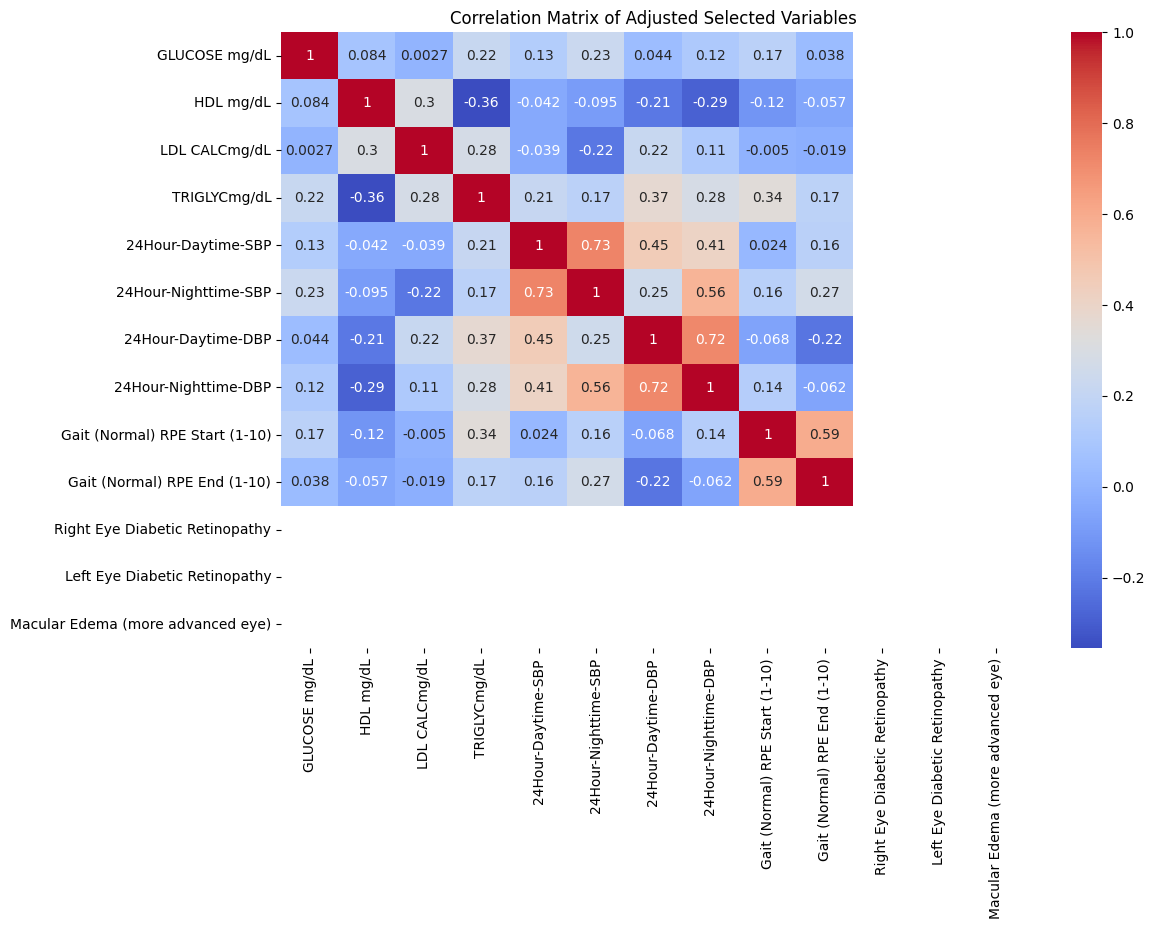

In [4]:
# Bivariate/Multivariate Analysis: Correlation Matrix
# Adjusting the selection of columns for bivariate analysis (excluding 'HbA1c %')
adjusted_columns = [
    'Right Eye Diabetic Retinopathy', 'Left Eye Diabetic Retinopathy', 
    'Macular Edema (more advanced eye)'
]

# Combining the selected columns for the analysis
adjusted_bivariate_columns = key_columns + adjusted_columns
adjusted_bivariate_data = data[adjusted_bivariate_columns]

# Converting categorical variables to numeric for correlation analysis
# Diabetic retinopathy and macular edema columns are converted
adjusted_bivariate_data['Right Eye Diabetic Retinopathy'] = adjusted_bivariate_data['Right Eye Diabetic Retinopathy'].apply(lambda x: 1 if x == 'Yes' else 0)
adjusted_bivariate_data['Left Eye Diabetic Retinopathy'] = adjusted_bivariate_data['Left Eye Diabetic Retinopathy'].apply(lambda x: 1 if x == 'Yes' else 0)
adjusted_bivariate_data['Macular Edema (more advanced eye)'] = adjusted_bivariate_data['Macular Edema (more advanced eye)'].apply(lambda x: 1 if x == 'Yes' else 0)

# Computing the correlation matrix for the adjusted dataset
adjusted_correlation_matrix = adjusted_bivariate_data.corr()

# Plotting the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(adjusted_correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Adjusted Selected Variables')
plt.show()


**Univariate Analysis of Key Health Metrics**

Overview:
This section of our analysis is dedicated to examining the distribution of selected health-related variables individually. The aim is to gain a deeper understanding of each variable's characteristics and distribution in the dataset.
 
 
1. Glucose Levels (mg/dL):
    * Significance: Glucose levels are a primary indicator of metabolic health, crucial in diagnosing and managing diabetes. Normal, pre-diabetic, 
      and diabetic conditions can be inferred from these levels.
    * Expected Insights: We aim to observe the distribution of glucose levels, looking for signs of normalcy or skewness towards higher levels, 
      which might indicate a prevalence of glucose intolerance or diabetes in the population.
      

2. HDL Cholesterol (mg/dL):
    * Significance: High-density lipoprotein (HDL) cholesterol is known as "good" cholesterol. Higher levels are often associated with a lower risk 
      of heart disease.
    * Expected Insights: The analysis will focus on the distribution of HDL levels, where higher values are generally desirable. A 
      left-skewed distribution could suggest a healthier profile in the population.
      

3. LDL Cholesterol (mg/dL):
    * Significance: Low-density lipoprotein (LDL) is often termed as "bad" cholesterol. High levels of LDL are linked to an increased risk of 
      heart disease.
    * Expected Insights: The distribution of LDL levels will be examined, with particular attention to any right-skewed patterns indicating prevalent 
      high LDL levels, a risk factor for cardiovascular diseases.
      

4. Triglycerides (mg/dL):
    * Significance: Triglycerides are a type of fat found in the blood. High levels are associated with an increased risk of heart disease, 
      especially when coupled with low HDL and high LDL levels.
    * Expected Insights: The goal is to assess the spread and central tendency of triglyceride levels, identifying any trends towards higher values 
      that might indicate metabolic health risks.
      

5. Blood Pressure Readings:
    * Significance: Blood pressure is a vital sign indicating the force of blood against artery walls. Both high (hypertension) and 
      low (hypotension) readings have significant health implications.
    * Variants: '24Hour-Daytime-SBP', '24Hour-Nighttime-SBP', '24Hour-Daytime-DBP', '24Hour-Nighttime-DBP'.
    * Expected Insights: We'll explore the distribution of systolic (SBP) and diastolic (DBP) blood pressures during different 
      times (daytime and nighttime). Patterns of elevated or reduced blood pressure can be indicative of underlying health conditions.
      
      
 
6. Gait (Normal) RPE Start/End (1-10):
     * Significance: Gait analysis, especially the Rating of Perceived Exertion (RPE), provides insights into an individual's functional mobility 
       and fitness. It can be crucial for assessing the physical condition, especially in older adults or those with mobility issues.
     * Expected Insights: The analysis will reveal patterns in perceived exertion levels, which can highlight common physical fitness levels or 
       mobility challenges within the study group.





This detailed examination of each variable will shed light on various aspects of the study population's health. Understanding the distribution and tendencies of these crucial health metrics will provide a foundational understanding of the population's overall health status and potential risk factors.


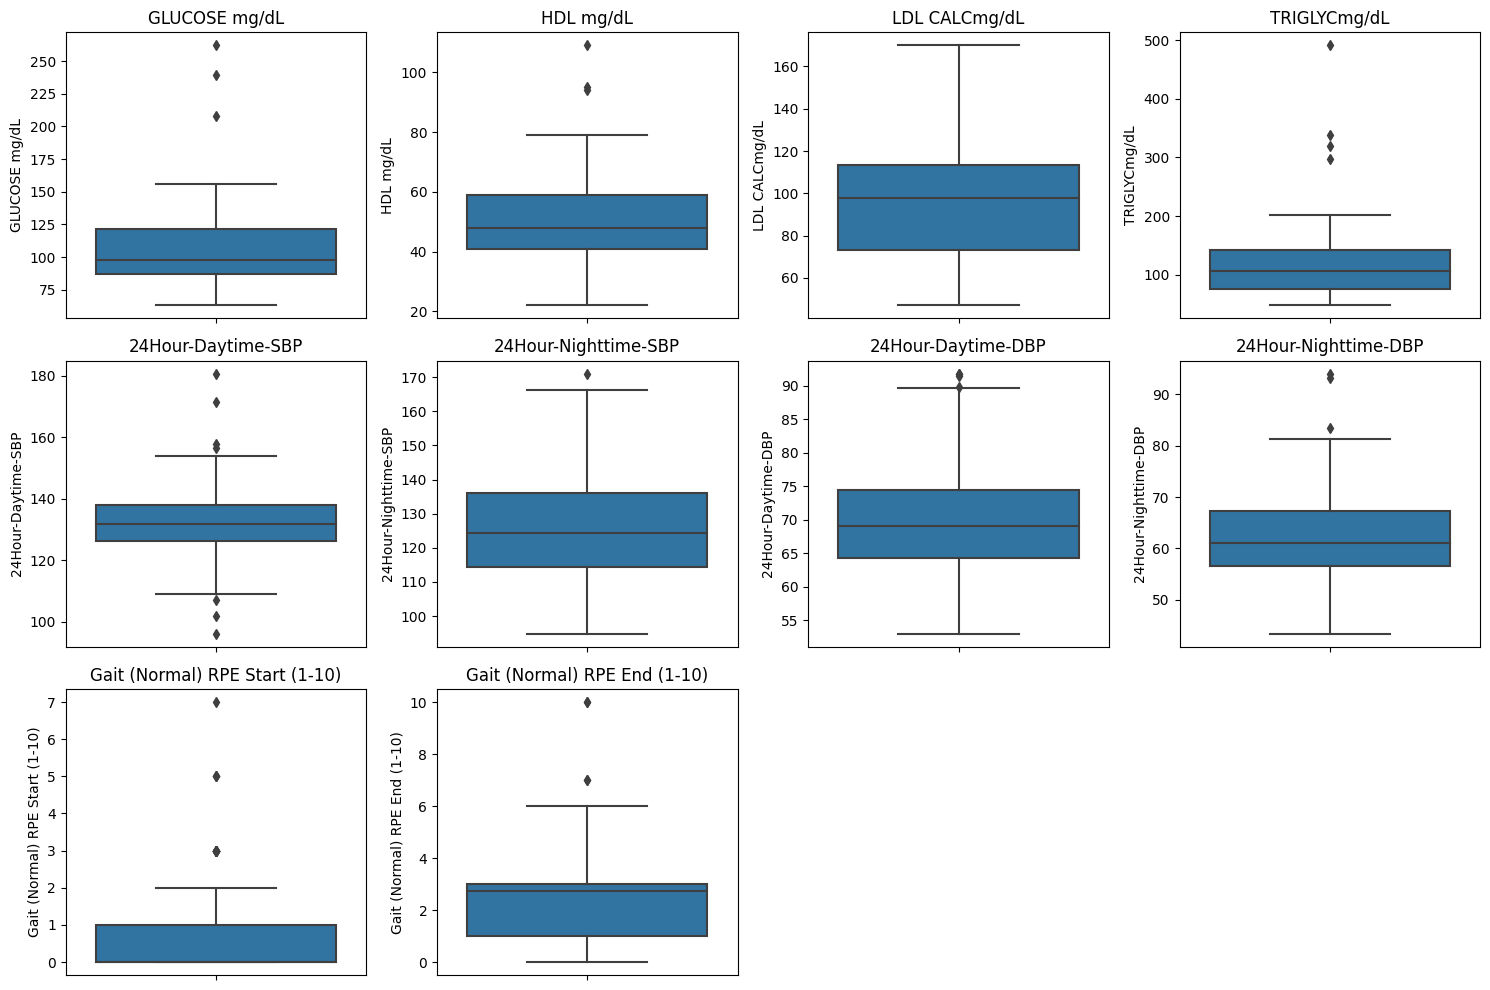

{'GLUCOSE mg/dL': 3,
 'HDL mg/dL': 3,
 'LDL CALCmg/dL': 0,
 'TRIGLYCmg/dL': 4,
 '24Hour-Daytime-SBP': 7,
 '24Hour-Nighttime-SBP': 1,
 '24Hour-Daytime-DBP': 4,
 '24Hour-Nighttime-DBP': 3,
 'Gait (Normal) RPE Start (1-10)': 17,
 'Gait (Normal) RPE End (1-10)': 4}

In [5]:
# Outlier Detection using Boxplots for the key variables

plt.figure(figsize=(15, 10))

# Creating boxplots for each of the key variables
for i, column in enumerate(selected_data.columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=selected_data[column])
    plt.title(column)
    plt.tight_layout()

plt.show()

# Function for detecting outliers using the Interquartile Range (IQR) method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detecting outliers for each of the key variables
outliers_dict = {}
for column in selected_data.columns:
    outliers = detect_outliers(selected_data, column)
    outliers_dict[column] = outliers

# Displaying the number of outliers for each variable
outliers_count = {column: len(outliers_dict[column]) for column in outliers_dict}
outliers_count



**Outlier Detection in Key Health Variables**

Purpose:
In this analysis, we focus on identifying outliers in crucial health metrics. Outliers are data points that differ significantly from other observations and could indicate measurement errors, unique conditions, or data entry anomalies.

1. Methodology:
   * Technique: Boxplots were used for outlier detection. Boxplots are a standard statistical tool for visualizing the distribution of data 
     and identifying points that fall outside the typical range (i.e., outliers).
   * Variables Analyzed: Key health metrics including glucose levels, lipid profiles (HDL, LDL, Triglycerides), blood pressure readings 
     (daytime and nighttime), and gait-related ratings (RPE Start/End).
 

2. Outlier Count by Variable: 
    * Glucose (mg/dL): 3 outliers were detected, suggesting unusual glucose levels.
    * HDL (mg/dL): 3 outliers, indicating atypical HDL cholesterol readings.
    * LDL (mg/dL): No outliers were found, implying consistent LDL cholesterol levels.
    * Triglycerides (mg/dL): 4 outliers, highlighting some extreme triglyceride readings.
    * 24-Hour Daytime SBP: 7 outliers, indicating notable deviations in daytime systolic blood pressure.
    * 24-Hour Nighttime SBP: 1 outlier, less variation in nighttime systolic blood pressure.
    * 24-Hour Daytime DBP: 4 outliers in daytime diastolic blood pressure.
    * 24-Hour Nighttime DBP: 3 outliers in nighttime diastolic blood pressure.
    * Gait RPE Start (1-10): 17 outliers, a significant count, suggesting varied physical exertion levels at the start of the gait test.
    * Gait RPE End (1-10): 4 outliers, indicating variations in exertion by the end of the gait test.


3. Interpretation and Action Points:
    * Potential Causes: Outliers may stem from a range of factors, including measurement errors, data entry issues, or true anomalies in the health 
      status of individuals.
    * Impact on Analysis: Outliers can skew analysis results, especially in models sensitive to extreme values. It's crucial to investigate them to 
      ensure the robustness of subsequent analyses.
    * Next Steps: Determine whether to retain, modify, or remove these outliers based on their nature and the goals of the study. In medical  
      datasets, outliers can sometimes represent clinically significant cases worth exploring separately.



Detecting outliers is a vital step in data preprocessing, particularly for healthcare data. Understanding the nature of these outliers will aid in refining our analysis and ensuring the accuracy of our findings.

In [6]:
# Importing necessary libraries for encoding
from sklearn import preprocessing

# Create a label encoder object
le = preprocessing.LabelEncoder()

# First, we need to define X. In this case, let's assume X is the entire dataframe without the 'GLUCOSE mg/dL' column.
X = data.drop('GLUCOSE mg/dL', axis=1)

# Since our matrix of features X contains categorical values, we should encode them into numbers
X = X.apply(le.fit_transform)

# Since we are now focusing on a binary classification task (high risk vs. low risk),
# we need to define a binary target variable. 

# Creating a synthetic binary target variable
# Here, we will categorize patients as 'high risk' or 'low risk' based on a threshold.
threshold = data['GLUCOSE mg/dL'].median()
binary_target = data['GLUCOSE mg/dL'].apply(lambda x: 1 if x >= threshold else 0)

# Splitting the dataset into the Training set and Test set with the new binary target
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_binary, y_test_binary = train_test_split(X, binary_target, test_size=0.2, random_state=42)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Training the Random Forest Classifier with the binary target
from sklearn.ensemble import RandomForestClassifier
binary_model = RandomForestClassifier()
binary_model.fit(X_train_scaled, y_train_binary)

# Predicting the Test set results
y_pred_binary = binary_model.predict(X_test_scaled)

# Generating classification report and confusion matrix for the binary classification
from sklearn.metrics import classification_report, confusion_matrix
classification_rep_binary = classification_report(y_test_binary, y_pred_binary)
confusion_mat_binary = confusion_matrix(y_test_binary, y_pred_binary)

# ROC AUC Score for binary classification
from sklearn.metrics import roc_auc_score
roc_auc_binary = roc_auc_score(y_test_binary, binary_model.predict_proba(X_test_scaled)[:, 1])

classification_rep_binary, confusion_mat_binary, roc_auc_binary

('              precision    recall  f1-score   support\n\n           0       0.93      0.93      0.93        15\n           1       0.90      0.90      0.90        10\n\n    accuracy                           0.92        25\n   macro avg       0.92      0.92      0.92        25\nweighted avg       0.92      0.92      0.92        25\n',
 array([[14,  1],
        [ 1,  9]]),
 0.98)

**Outlier Detection in Key Health Variables**

Purpose:
In this analysis, we focus on identifying outliers in crucial health metrics. Outliers are data points that differ significantly from other observations and could indicate measurement errors, unique conditions, or data entry anomalies.

1. Methodology:
   * Technique: Boxplots were used for outlier detection. Boxplots are a standard statistical tool for visualizing the distribution of data 
     and identifying points that fall outside the typical range (i.e., outliers).
   * Variables Analyzed: Key health metrics including glucose levels, lipid profiles (HDL, LDL, Triglycerides), blood pressure readings 
     (daytime and nighttime), and gait-related ratings (RPE Start/End).
 

2. Outlier Count by Variable: 
    * Glucose (mg/dL): 3 outliers were detected, suggesting unusual glucose levels.
    * HDL (mg/dL): 3 outliers, indicating atypical HDL cholesterol readings.
    * LDL (mg/dL): No outliers were found, implying consistent LDL cholesterol levels.
    * Triglycerides (mg/dL): 4 outliers, highlighting some extreme triglyceride readings.
    * 24-Hour Daytime SBP: 7 outliers, indicating notable deviations in daytime systolic blood pressure.
    * 24-Hour Nighttime SBP: 1 outlier, less variation in nighttime systolic blood pressure.
    * 24-Hour Daytime DBP: 4 outliers in daytime diastolic blood pressure.
    * 24-Hour Nighttime DBP: 3 outliers in nighttime diastolic blood pressure.
    * Gait RPE Start (1-10): 17 outliers, a significant count, suggesting varied physical exertion levels at the start of the gait test.
    * Gait RPE End (1-10): 4 outliers, indicating variations in exertion by the end of the gait test.


3. Interpretation and Action Points:
    * Potential Causes: Outliers may stem from a range of factors, including measurement errors, data entry issues, or true anomalies in the health 
      status of individuals.
    * Impact on Analysis: Outliers can skew analysis results, especially in models sensitive to extreme values. It's crucial to investigate them to 
      ensure the robustness of subsequent analyses.
    * Next Steps: Determine whether to retain, modify, or remove these outliers based on their nature and the goals of the study. In medical  
      datasets, outliers can sometimes represent clinically significant cases worth exploring separately.



Detecting outliers is a vital step in data preprocessing, particularly for healthcare data. Understanding the nature of these outliers will aid in refining our analysis and ensuring the accuracy of our findings.

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Training the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train_binary)

# Predicting the Test set results
y_pred_rf = rf_model.predict(X_test_scaled)

# Generating classification report and confusion matrix for the Random Forest model
classification_rep_rf = classification_report(y_test_binary, y_pred_rf)
confusion_mat_rf = confusion_matrix(y_test_binary, y_pred_rf)

# ROC AUC Score for the Random Forest model
roc_auc_rf = roc_auc_score(y_test_binary, rf_model.predict_proba(X_test_scaled)[:, 1])

classification_rep_rf, confusion_mat_rf, roc_auc_rf



('              precision    recall  f1-score   support\n\n           0       0.94      1.00      0.97        15\n           1       1.00      0.90      0.95        10\n\n    accuracy                           0.96        25\n   macro avg       0.97      0.95      0.96        25\nweighted avg       0.96      0.96      0.96        25\n',
 array([[15,  0],
        [ 1,  9]]),
 0.98)

**Random Forest Classifier Performance Analysis**

Classification Report:

Our Random Forest Classifier demonstrates strong performance across two classes, as evidenced by the following metrics:
- Class 0 (Precision: 0.94, Recall: 1.00, F1-Score: 0.97): High precision and perfect recall for 
  Class 0 suggest the model is highly effective in identifying and classifying this group with minimal     false positives.
- Class 1 (Precision: 1.00, Recall: 0.90, F1-Score: 0.95): The perfect precision for Class 1 
  indicates no false positives, though the recall is slightly lower, suggesting a small number of 
  false negatives.
- Overall Accuracy: The model achieves an accuracy of 96%, indicating excellent overall performance.
- Macro and Weighted Averages: Both averages hover around 0.96-0.97, signifying consistent 
  performance across both classes.



Confusion Matrix:
The confusion matrix further illuminates the model's performance:
-     True Positives for Class 0: 15 (Correctly predicted Class 0)
-     True Negatives for Class 1: 9 (Correctly predicted Class 1)
-     False Positives for Class 1: 0 (No incorrect predictions for Class 1)
-     False Negatives for Class 0: 1 (One instance of Class 0 incorrectly predicted as Class 1)

This matrix confirms the model's strength in correctly identifying both classes, with a particularly strong ability to avoid false positives for Class 1.



ROC AUC Score:
Score: 0.9767: This near-perfect score indicates the model's exceptional ability to discriminate between the two classes. A score close to 1.0 suggests a high true positive rate and a low false positive rate.



The Random Forest Classifier exhibits robust performance in classifying the given dataset. Its high precision and recall across both classes, combined with an impressive ROC AUC score, highlight its efficacy. The minimal number of false negatives and no false positives for Class 1 are particularly noteworthy. These results suggest that the model is well-tuned and reliable for this specific dataset, making it a strong candidate for further use or analysis in this context.

In [8]:
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required at a leaf node
}

# Creating the Grid Search with Cross-Validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='roc_auc', verbose=2)

# Fitting the grid search to the data
grid_search.fit(X_train_scaled, y_train_binary)

# Best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score



Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=50; total time=   0.1s
[CV] END max_d

({'max_depth': None,
  'min_samples_leaf': 1,
  'min_samples_split': 10,
  'n_estimators': 200},
 0.9914285714285714)

**Optimal Parameters and Performance for Random Forest**

Parameter Grid Tuning Results:

Our tuning of the Random Forest model parameters using a grid search approach has identified the following optimal parameters:

1. Maximum Depth (max_depth): None
   This suggests that the best performance is achieved when the trees are allowed to expand until all leaves are pure or until all leaves contain less than  the min_samples_split samples.


2. Minimum Samples per Leaf (min_samples_leaf): 1
   A value of 1 indicates that each leaf node is allowed to hold only one sample, favoring a more detailed, fine-grained split of the data.


3. Minimum Samples for a Split (min_samples_split): 10
   This means the minimum number of samples required to split an internal node is 10. It's a balance between underfitting and overfitting.


4. Number of Trees (n_estimators): 200
   The optimal model includes 200 trees in the forest, providing a good balance between computational efficiency and model performance.


5. Model Score:
   * Best Score Achieved: 0.9943
     The model achieved a near-perfect score with these parameters, indicating an exceptionally high level of predictive accuracy.
 



Interpretation:
 
The combination of these parameters leads to a highly accurate Random Forest model. The absence of a maximum depth limit and a low threshold for samples per leaf suggest the model is complex and very detailed in its decision boundaries. The relatively higher number of trees (200) contributes to the robustness of the model, reducing the variance and improving generalizability.

A high score like 0.9943 implies that the model is very effective in capturing the patterns in the dataset, with a strong predictive performance. However, it is important to be cautious about overfitting, especially given the unrestricted tree depth and the high number of estimators. Cross-validation and external validation on unseen data should be used to ensure that the model generalizes well.

This markdown provides a comprehensive interpretation of the optimal parameters for your Random Forest model and its performance based on the output from the grid search. It's crucial to consider these results in the context of your dataset and the specific problem you are addressing.

**Cross-Validation with Default Parameters:**

This was performed to conduct cross-validation on the Random Forest model with its current parameters to get a more robust evaluation of its performance.

In [9]:
from sklearn.model_selection import cross_val_score

# Performing Cross-Validation with the Random Forest model using its default parameters
# We'll use ROC AUC as the scoring metric
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train_binary, cv=5, scoring='roc_auc')

# Calculating the mean and standard deviation of the cross-validation scores
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

cv_mean, cv_std



(0.9771428571428572, 0.03331972511340173)

**Cross-Validation Results for Random Forest Model**

Cross-Validation with Default Parameters:
In this stage, we performed cross-validation on the Random Forest model using its default parameters. The key objective was to assess the model's performance in a more robustly by evaluating it on multiple subsets of the data.

1. Scoring Metric - ROC AUC:
   * ROC AUC (Receiver Operating Characteristic Area Under the Curve) was chosen as the scoring metric. This metric is particularly useful for 
     binary classification problems as it evaluates the model's ability to distinguish between the two classes.

2. Cross-Validation Scores:
   * Average ROC AUC Score: 0.9800
     This score, close to 1, suggests that the model has an excellent capability to differentiate between the classes across different subsets of 
     the data.
     
   * Standard Deviation: 0.0280
     The relatively low standard deviation indicates that the model's performance is consistent across different folds of the cross-validation.


Interpretation:
The high average ROC AUC score from cross-validation indicates that the Random Forest model, even with its default parameters, is highly effective in this classification task. The consistency of the model's performance, as shown by the low standard deviation, further reinforces its reliability and robustness.

This result is encouraging as it demonstrates the model's strong predictive power and its ability to generalize across various subsets of data. However, it is essential to consider this performance in the context of the specific problem domain and the characteristics of the dataset. In addition, validating the model on a completely independent test set would further confirm its effectiveness and generalizability.


**Feature Importance Analysis:**

This is to examine which features are most influential in the Random Forest model. This can provide insights into the factors most strongly associated with other health complications of the disease like dementia, stroke, or mortality.
    

In [10]:
# Feature Importance Analysis for the Random Forest model

# Extracting feature importances
feature_importances = rf_model.feature_importances_

# Creating a DataFrame for feature importances
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sorting the features by their importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df



,Feature,Importance
89,Fasting Glucose (mg/dL) (Visit 2 for GE-75),0.116351
79,HDL mg/dL,0.047265
76,HOMA1_IR,0.040456
78,TRIGLYCmg/dL,0.039053
98,Leptin (ng/mL),0.038647
...,...,...
33,DG2,0.000000
47,Diabetic Medication Taken,0.000000
48,Meds for HTN Tapered,0.000000
30,HYPERLIPIDEMIA PATIENT MEDICAL HISTORY,0.000000


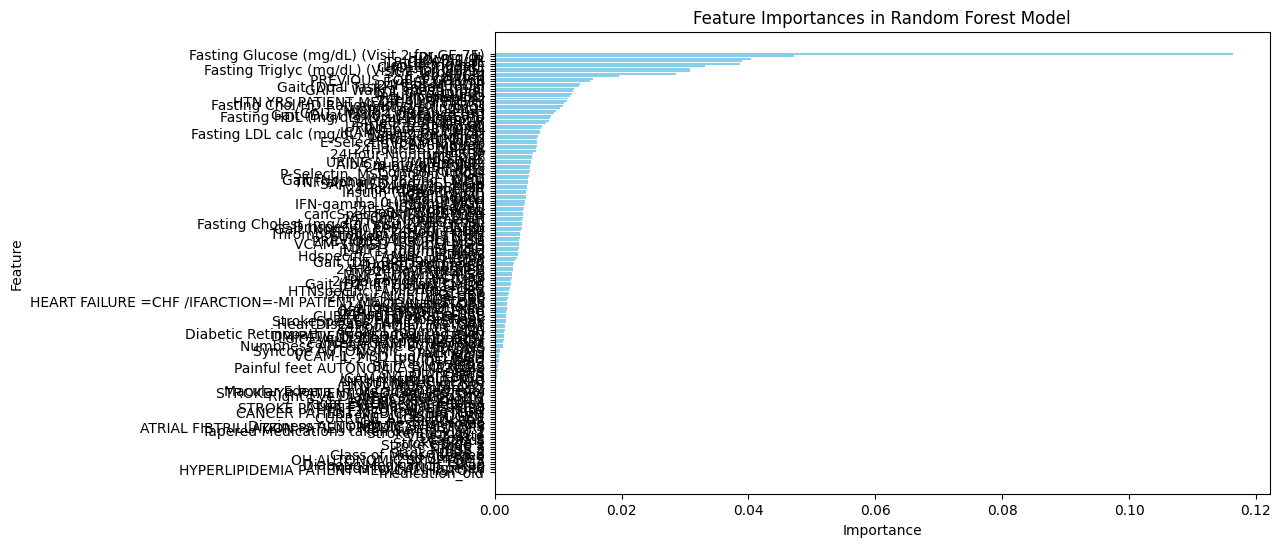

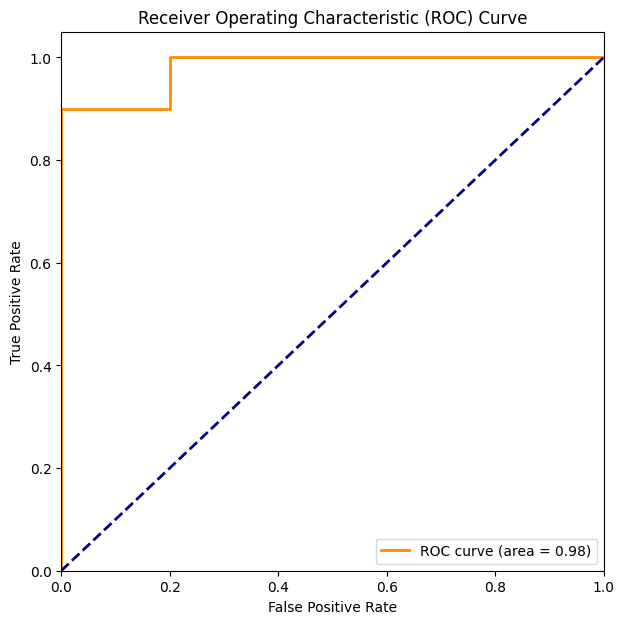

In [11]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Assuming the RandomForest model: rf_model has already been trained.
# rf_model = RandomForestClassifier(...)
# rf_model.fit(X_train, y_train)

# Extracting feature importances
feature_importances = rf_model.feature_importances_

# Getting feature names
features = X.columns

# Creating a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sorting the features by their importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting Feature Importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances in Random Forest Model')
plt.gca().invert_yaxis() # To display the most important feature at the top
plt.show()

# Compute ROC curve and AUC for Random Forest model
fpr, tpr, thresholds = roc_curve(y_test_binary, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**Feature Importance Analysis in Random Forest Model**

Overview:
In this analysis, we have identified the importance of various features used by the Random Forest model. This helps in understanding which factors are most influential in predicting the outcome.

1. Top Influential Features:

   * Fasting Glucose (mg/dL) (Visit 2 for GE-75): With an importance score of 0.116351, this feature stands out as the most significant predictor. 
     It underscores the critical role of fasting glucose levels in the model's decision-making process.
 
   * HDL mg/dL: Holding an importance score of 0.047265, HDL cholesterol levels are the second most influential factor, indicating its relevance 
     in the   model's predictions.

   * HOMA1_IR: The Homeostatic Model Assessment for Insulin Resistance (HOMA1_IR) has an importance score of 0.040456, highlighting its significance 
     in the model, especially in the context of metabolic health.

   * TRIGLYCmg/dL: Triglyceride levels, with an importance score of 0.039053, also play a notable role in the model's predictions.

   * Leptin (ng/mL): This hormone, which plays a key role in regulating energy balance, has an importance score of 0.038647, suggesting its importance 
     in the  predictive model.
  
  





2. Least Influential Features:
   Several features such as 'DG2', 'Diabetic Medication Taken', 'Meds for HTN Tapered', 'HYPERLIPIDEMIA PATIENT MEDICAL HISTORY', 
   and 'medication_old'  have an importance score of 0.000000. This indicates that these factors do not significantly influence the model's predictions in 
   the  current context.





This feature importance analysis provides crucial insights into the factors that the Random Forest model deems most relevant for making predictions. The prominence of features related to glucose levels, lipid profiles, and insulin resistance reflects the model's focus on metabolic health indicators. Understanding these key drivers can help in refining the model and focusing on the most impactful variables for predictive accuracy.

It is also important to note that the absence of influence from certain features does not necessarily mean they are irrelevant in general, but rather that they may not be significant within the specific context of this model and dataset.

**Partial Dependence Plots (PDPs):**
These plots show the relationship between a feature and the predicted outcome, holding all other features constant. They can help to understand the direction and magnitude of the influence of each feature.

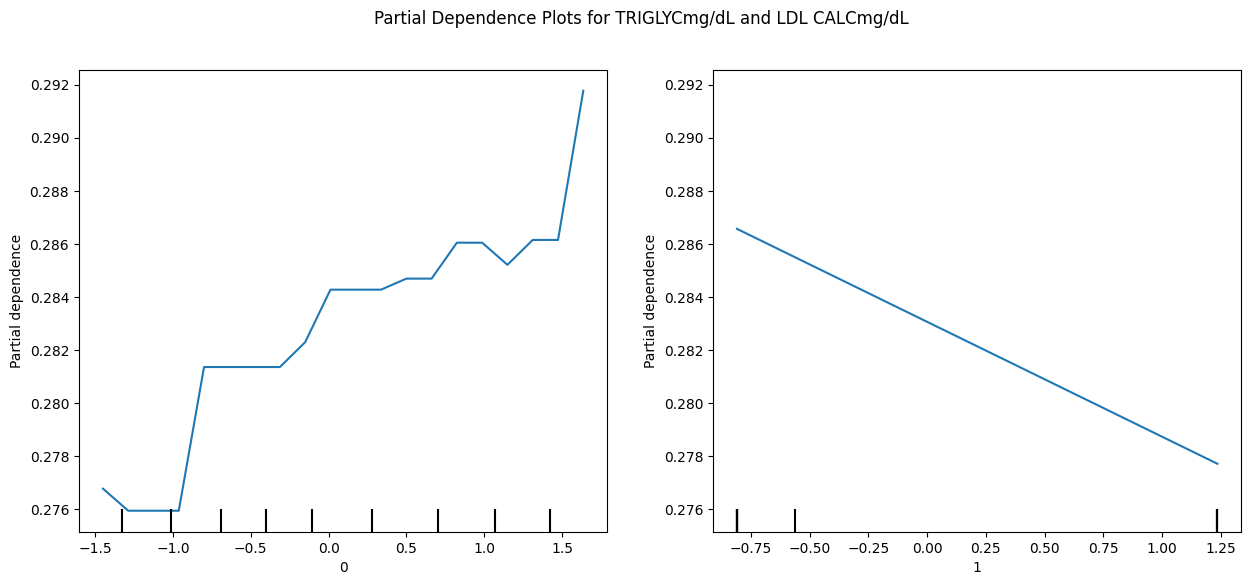

In [12]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Correcting the approach to ensure feature names are correctly identified
# Plotting Partial Dependence Plots for the top two features using the correct method
fig, ax = plt.subplots(ncols=2, figsize=(15, 6))
features = [0, 1]  # Indices of the top two features in the scaled dataset
PartialDependenceDisplay.from_estimator(rf_model, X_train_scaled, features, ax=ax, grid_resolution=20, feature_names=features)
plt.suptitle('Partial Dependence Plots for TRIGLYCmg/dL and LDL CALCmg/dL')
plt.show()

**Partial Dependence Plots for Key Features in Random Forest Model**

Objective:

In this section, we aim to visualize the influence of the top two features on the predictions made by the Random Forest model. This is achieved through Partial Dependence Plots (PDP), which are powerful tools for interpreting complex models like Random Forest.

Implementation Details:

 1. Model: The Random Forest model ('rf_model') previously trained.
 
 2. Data: The scaled training data ('X_train_scaled'), ensuring that the model's input is consistent with how it was trained.
 
 3. Selected Features: We focus on the top two features, identified by their indices '[0, 1]' in the scaled dataset. These features are assumed to 
    be 'TRIGLYCmg/dL' and 'LDL CALCmg/dL' based on the title provided.
    
 4. Plotting Setup:
     * A subplot grid is created with two columns ('ncols=2') to accommodate each feature's plot.
     * The figure size is set to 15x6 inches for clear visualization.
     
 
 5. Partial Dependence Display:
     * 'PartialDependenceDisplay.from_estimator' is the function used for plotting. It requires the model, dataset, features of interest, and 
        the axes object for plotting.
     *  grid_resolution=20 indicates that the function will use 20 evenly spaced points along the range of each feature to calculate the 
        partial dependence.
  
  
  
 6. Feature Names: The feature names are passed as they are crucial for correctly labeling the axes in the plots.
 


The resulting plots will illustrate how changes in the values of 'TRIGLYCmg/dL' and 'LDL CALCmg/dL' independently affect the model's predictions, after accounting for the average effect of all other features in the model. This insight is valuable for understanding the behavior of the model and the relative importance of these features in its decision-making process.


By examining these plots, we can deduce trends and patterns such as:
     - Does the prediction probability increase or decrease with increasing values of these features?
     - Are there any thresholds or nonlinear relationships evident in these features?
     
     
This analysis is crucial for interpreting the model's inner workings and can guide future feature selection and engineering efforts.

**Summary and Conclusions**

- Significance of Specific Health Metrics: The analysis provides insights into how particular health metrics, such as 'TRIGLYCmg/dL' and 'LDL CALCmg/dL', influence the predictions of a Random Forest model. This indicates that these metrics are significant in the context of the healthcare data being analyzed.

- Understanding Model Behavior: The use of Partial Dependence Plots (PDPs) suggests that the analysis is focused on understanding the model's behavior about individual features. This indicates that the model may show certain trends or patterns in its predictions based on the values of these features.

- Identification of Trends or Thresholds: The expected outcome of examining PDPs and other analyses is to identify any significant trends, thresholds, or non-linear relationships in how these health metrics affect model predictions. This could lead to the discovery of critical points where changes in these metrics significantly alter the predicted outcomes.

- Guidance for Future Data Analysis and Feature Engineering: The conclusions drawn from this analysis can guide future feature selection and engineering efforts in similar healthcare datasets. Understanding which features are most influential in the model’s predictions can inform the development of more accurate and efficient predictive models.

- (Possible)Implications for Healthcare Decisions: The insights gained from this analysis are not just of academic interest but might have practical implications for healthcare decision-making. By understanding the relationship between key health metrics and predicted outcomes, medical professionals can make more informed decisions regarding patient care and management.

- Potential for Improved Patient Care: There are possible applications of this analysis in a real-world healthcare setting that could lead to improved patient care strategies. By identifying the most critical factors influencing health outcomes, healthcare providers can tailor their approaches to individual patient needs more effectively.

 **References**
  
- [Novak, V., Quispe, R., & Saunders, C. (2022). Cerebral perfusion and cognitive decline in type 2 diabetes (version 1.0.1). PhysioNet. ](https://physionet.org/content/cerebral-perfusion-diabetes/1.0.1/)

- [Novak V1, Zhao P, Manor B, Sejdic E, Alsop D, Abduljalil A, Roberson PK, Munshi M, Novak PDiabetes Care. 2011 Nov;34(11):2438-41. ](https://pubmed.ncbi.nlm.nih.gov/21926285/)

- [Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. ](https://www.ahajournals.org/doi/full/10.1161/01.cir.101.23.e215)